SUPERSTORE SALES PERFORMANCE ANALYSIS

Objective:

Evaluate regional and product-level profitability performance and **identify structural drivers of margin erosion** and quantify the directional impact of improved pricing discipline.

---

# Executive Summary

## Overview
This analysis evaluated Superstore’s sales and profitability performance to identify structural drivers of margin variability across regions and product categories. While overall performance appears stable at the aggregate level (12.47% margin), segmentation analysis reveals localized inefficiencies.

---

## Key Findings

### 1. Company-Level Performance Is Stable
Monthly trend analysis shows that sales and profit generally move together over time, with no evidence of sustained company-wide margin deterioration. This suggests that performance concerns are not systemic but are likely concentrated within specific segments.

### 2. Regional Margin Dispersion Exists
Regional benchmarking reveals meaningful variation in profitability:

- West and East operate above the average regional margin.
- Central underperforms materially, indicating structural inefficiencies relative to peer regions.

This suggests potential differences in pricing discipline, cost structure, or product mix.

### 3. Furniture Is Margin-Dilutive
Although revenue contribution across categories is balanced, profit contribution is highly uneven.

Furniture generates over 32% of total revenue but contributes only ~6% of total profit due to a significantly lower profit margin (2.5%). In contrast, Technology and Office Supplies demonstrate substantially higher margin efficiency.

This indicates that revenue growth within Furniture does not translate proportionally into profitability.

### 4. Margin Erosion Is Concentrated in Tables (East Region)
Sub-category analysis reveals that Furniture underperformance is concentrated in Tables and Bookcases, both of which are loss-making.

Further regional decomposition shows that Tables losses are disproportionately concentrated in the East region, where the average discount rate (37.4%) is significantly higher than other regions.

Discount sensitivity analysis confirms a strong negative relationship between discount levels and profitability, while showing negligible impact on quantity sold. This indicates that aggressive discounting is not operating as an effective volume strategy.

---

## Scenario Analysis - Pricing Intervention
A simplified scenario reducing the East region Tables discount from 37.4% to 25% (holding volume constant) results in an estimated profit improvement of approximately $8,100 — reducing losses by nearly 73%.

While Tables remain slightly unprofitable under this assumption, the magnitude of improvement confirms pricing discipline as a high-impact lever.

---

## Recommendation
- Prioritize discount control for Tables in the East region.
- Focus corrective action on loss-making sub-categories rather than broad Furniture-wide adjustments.
- Monitor profitability response to pricing interventions before implementing further structural changes.

---

Analytical Roadmap:

This analysis follows a structured diagnostic approach:

1. Data Preparation and Validation  
2. Executive KPI Assessment  
3. Revenue and Profit Trend Analysis  
4. Regional Performance Benchmarking  
5. Category Profitability Assessment  
6. Furniture Sub-Category Diagnostic  
7. Discount Sensitivity and Volume Trade-Off  
8. Scenario Analysis – Pricing Intervention  
9. Recommendations and Next Steps

1. DATA PREPARATION AND VALIDATION

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Loading the dataset
salesdata = pd.read_csv("superstore.csv", encoding = "latin-1")
salesdata.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
salesdata.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [3]:
salesdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
#Convert date fields.
salesdata['Order Date'] = pd.to_datetime(salesdata['Order Date'])
salesdata['Ship Date'] = pd.to_datetime(salesdata['Ship Date'])

#postal code is an identifier and not a numeric for computation
salesdata['Postal Code'] = salesdata['Postal Code'].astype(str)

#convert repeated label fields to categorical
categorical_column = ['Region', 'Category', 'Sub-Category', 'Segment',
                      'Ship Mode', 'State']
for column in categorical_column:
    salesdata[column] = salesdata[column].astype('category')

#confirmation check
salesdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   category      
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   category      
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   category      
 11  Postal Code    9994 non-null   object        
 12  Region         9994 non-null   category      
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   category      
 15  Sub-Category   9994 n

In [5]:
#check for missing values
salesdata.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
#check for duplicates
salesdata.duplicated().sum()

np.int64(0)

2. EXECUTIVE KPI ASSESSMENT

In [7]:
#Total Sales, Total Profit and Profit margin
total_sales = salesdata['Sales'].sum()
total_profit = salesdata['Profit'].sum()

overall_profit_margin = total_profit/total_sales

profit_margin_percent = overall_profit_margin * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin_percent:.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%


**Executive Insight:**  
Superstore generated $2.3M in revenue with a 12.47% overall profit margin. At the aggregate level, performance appears stable. Further segmentation analysis is required to determine whether profitability varies across regions or product categories.


3. REVENUE AND PROFIT TREND ANALYSIS

In [8]:
#Create Year-Month column
salesdata['YearMonth'] = salesdata['Order Date'].dt.to_period('M')
monthly_sales = salesdata.groupby('YearMonth', observed=True)[['Sales', 'Profit']].sum()

monthly_sales.head()


,Sales,Profit
YearMonth,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


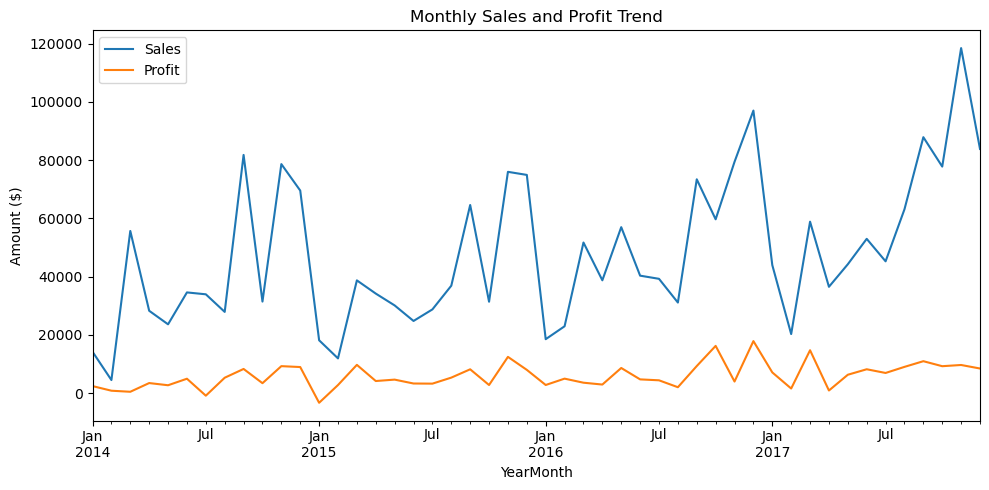

In [9]:
#Monthly Sales plot
monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales and Profit Trend')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.savefig("Monthly Sales Plot.png", dpi=300)
plt.show()



**Trend Insight:**  
Sales and profit generally move in the same direction over time, with observable seasonal fluctuations and short-term volatility. There is no clear evidence of sustained aggregate margin deterioration at the company level. Further segmentation analysis is required to determine whether profitability variations exist across regions or product categories.


4. REGIONAL PERFORMANCE BENCHMARKING

In [10]:
#Sales and Profit by Region
summary_by_region = salesdata.groupby('Region', observed=True)[['Sales', 'Profit']].sum()

#Margin per region
summary_by_region['Profit Margin'] = summary_by_region['Profit'] / summary_by_region ['Sales']

summary_by_region.sort_values(by='Sales', ascending=False)

,Sales,Profit,Profit Margin
Region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
Central,501239.8908,39706.3625,0.079216
South,391721.9050,46749.4303,0.119343


**Justification for using Mean as a baseline:**

To assess regional performance, the average (mean) across all regions is used as a baseline benchmark. This establishes a neutral reference point for comparing each region’s sales, profit, and profit margin against overall organizational performance.

This approach assumes that the four regions represent comparable operating units within a similar business structure. Since the dataset does not provide detailed organizational context, this assumption allows for relative performance evaluation while maintaining analytical consistency.

While more granular benchmarks (e.g., cost structure differences, regional market conditions, or historical trends) could refine the analysis, the mean serves as a practical and transparent starting point for identifying potential performance gaps and areas for improvement.

In [11]:
#compute benchmark
mean_sales = summary_by_region['Sales'].mean()
mean_profit = summary_by_region['Profit'].mean()
mean_margin = summary_by_region['Profit Margin'].mean()

#Benchmark comparison
summary_by_region['Sales vs Avg'] = summary_by_region['Sales'] - mean_sales
summary_by_region['Profit vs Avg'] = summary_by_region['Profit'] - mean_profit
summary_by_region['Margin vs Avg'] = summary_by_region['Profit Margin'] - mean_margin

summary_by_region.sort_values(by='Sales', ascending=False)

,Sales,Profit,Profit Margin,Sales vs Avg,Profit vs Avg,Margin vs Avg
Region,,,,,,
West,725457.8245,108418.4489,0.149448,151157.609425,36819.193475,0.028738
East,678781.2400,91522.7800,0.134834,104481.024925,19923.524575,0.014123
Central,501239.8908,39706.3625,0.079216,-73060.324275,-31892.892925,-0.041494
South,391721.9050,46749.4303,0.119343,-182578.310075,-24849.825125,-0.001367


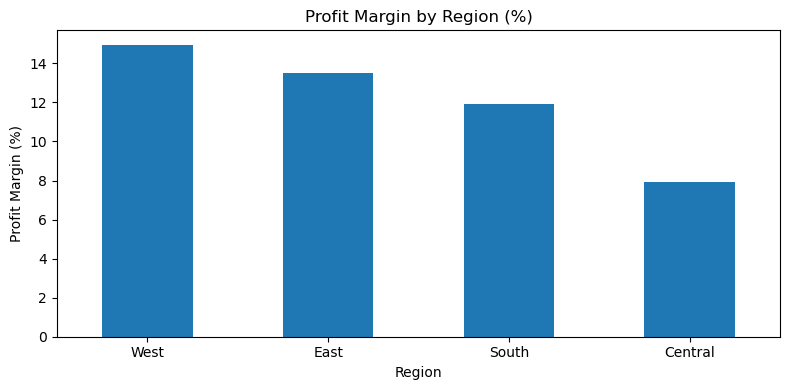

In [12]:
#Profit margin by region plot
(summary_by_region['Profit Margin']*100).sort_values(ascending=False).plot(kind='bar', figsize=(8,4))
plt.title("Profit Margin by Region (%)")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Profit Margin by Region.png", dpi=300)
plt.show()



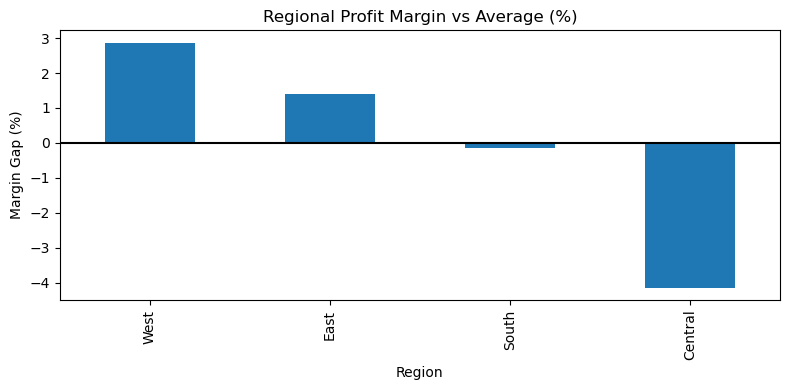

In [13]:
(summary_by_region['Margin vs Avg']*100).sort_values(ascending=False).plot(kind='bar', figsize=(8,4))
plt.axhline(0, color='black')
plt.title("Regional Profit Margin vs Average (%)")
plt.ylabel("Margin Gap (%)")
plt.tight_layout()
plt.savefig("Regional Profit Margin vs Avg.png", dpi=300)
plt.show()



**Regional benchmarking insight:**

Regional performance shows clear margin dispersion. West and East operate above the regional average margin benchmark, while Central underperforms materially. The margin gap suggests potential structural differences in pricing discipline, cost control, or product mix across regions presenting opportunities for targeted margin improvement initiatives.

5. CATEGORY PROFITABILITY ASSESSMENT

In [14]:
#Sales Profit by Category
summary_by_category = salesdata.groupby('Category', observed=True)[['Sales', 'Profit']].sum()
summary_by_category['Profit Margin'] = summary_by_category['Profit'] / summary_by_category['Sales']

#Calculate Contribution %
summary_by_category['Sales %'] = summary_by_category['Sales'] / summary_by_category['Sales'].sum()
summary_by_category['Profit %'] = summary_by_category['Profit'] / summary_by_category['Profit'].sum()

summary_by_category.sort_values(by='Sales', ascending=False)

,Sales,Profit,Profit Margin,Sales %,Profit %
Category,,,,,
Technology,836154.0330,145454.9481,0.173957,0.363988,0.507879
Furniture,741999.7953,18451.2728,0.024867,0.323002,0.064426
Office Supplies,719047.0320,122490.8008,0.170352,0.313010,0.427696


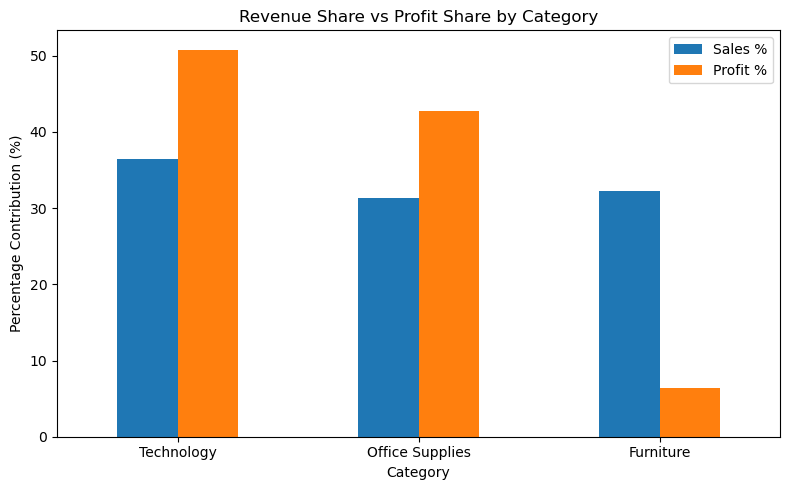

In [15]:
#Revenue share vs profit share (%)
category_contribution = summary_by_category[['Sales %','Profit %']] * 100
(category_contribution).sort_values(by='Profit %',ascending=False).plot(kind='bar', figsize=(8,5))

plt.title("Revenue Share vs Profit Share by Category")
plt.ylabel("Percentage Contribution (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Revenue Share vs Profit Share by Category.png", dpi=300)
plt.show()



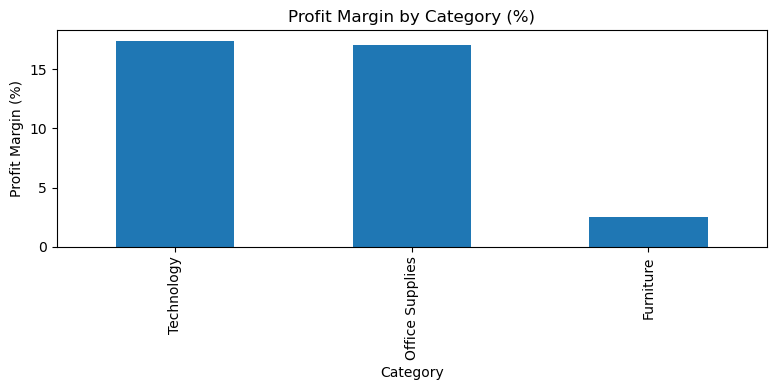

In [16]:
#Profit margin by category
(summary_by_category['Profit Margin']*100).sort_values(ascending=False).plot(kind='bar', figsize=(8,4))
plt.title("Profit Margin by Category (%)")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig("Profit Margin by Category (%).png", dpi=300)
plt.show()



**Category Profitability Assessment Insight:**

Revenue contribution is relatively balanced across categories; however, profit contribution is highly uneven. Furniture generates over 32% of revenue but contributes only ~6% of total profit due to materially lower margins. This indicates a margin-dilutive product mix relative to Technology and Office Supplies.


6. FURNITURE SUB-CATEGORY DIAGNOSTIC

In [17]:
#Why is furniture margin so low? Check average discount by category to see if discount is eating at profit.
salesdata.groupby('Category', observed=True)['Discount'].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

DISCOUNT IMPACT ASSESSMENT:

Furniture exhibits the highest average discount rate (17.4%) compared to Office Supplies (15.7%) and Technology (13.2%). While elevated discounting likely contributes to margin compression, the magnitude of Furniture’s margin gap (approximately 15% points lower than other categories) suggests that discount strategy alone does not fully explain its underperformance.
This indicates that additional structural factors—such as product mix, cost structure, or operational inefficiencies—may be materially affecting profitability within the Furniture segment.
Further sub-category and product-level analysis is required to isolate the primary drivers of margin erosion.

In [18]:
#Since discount strategy alone doesn't fully explain furniture's underperformance, we will analyse subcategory within furniture and see if one of them is dragging margins down.
furniture_data = salesdata[salesdata['Category'] == 'Furniture'].copy()
summary_of_furniture = furniture_data.groupby('Sub-Category',observed=True)[['Sales','Profit']].sum()
summary_of_furniture['Profit Margin'] = summary_of_furniture['Profit'] / summary_of_furniture['Sales']

#Drop zero sales if any
summary_of_furniture = summary_of_furniture[summary_of_furniture['Sales'] > 0]

summary_of_furniture.sort_values(by='Profit Margin')


,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Chairs,328449.1030,26590.1663,0.080957
Furnishings,91705.1640,13059.1436,0.142404


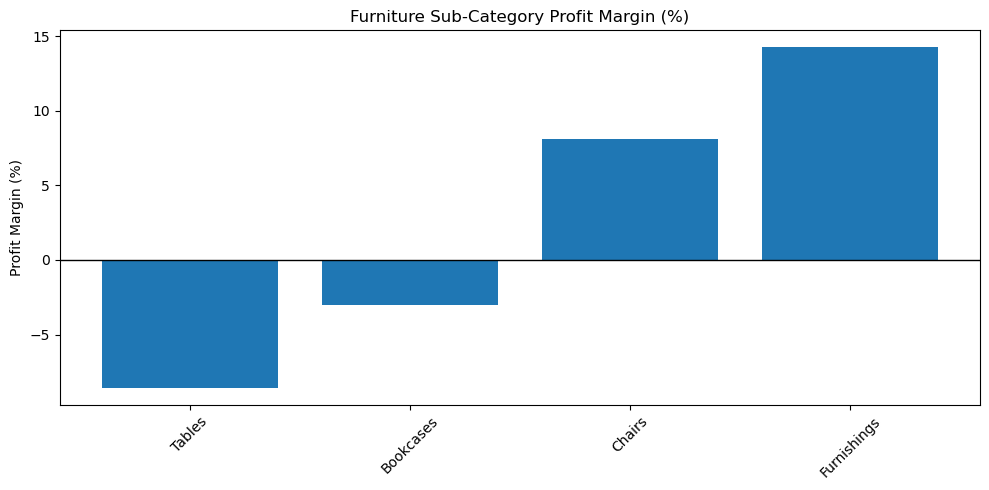

In [19]:
furniture_margin = (summary_of_furniture['Profit Margin'] * 100).sort_values()

plt.figure(figsize=(10,5))
bars = plt.bar(furniture_margin.index, furniture_margin)

# Add zero line
plt.axhline(0, color='black', linewidth=1)

plt.title("Furniture Sub-Category Profit Margin (%)")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Furniture Sub-Category Profit Margin (%).png", dpi=300)
plt.show()



**Sub-category Diagnostic Insight**
  
Furniture underperformance is concentrated in specific sub-categories. Tables and Bookcases are loss-making, while Chairs and Furnishings are profitable. The issue is therefore targeted rather than category-wide.
This indicates that targeted corrective action within specific product lines—rather than broad category-level adjustments—may yield more effective margin improvement.

7. DISCOUNT SENSITIVITY AND VOLUME TRADEOFF 

In [20]:
#Now, we will test discount behaviour specifically within Tables and Bookcases to see if discount is eating away at their profit
furniture_subcategory_loss = salesdata[salesdata['Sub-Category'].isin(['Tables','Bookcases'])].copy()
furniture_subcategory_loss['Sub-Category'] = furniture_subcategory_loss['Sub-Category'].cat.remove_unused_categories()
furniture_subcategory_loss.groupby('Sub-Category', observed=True)['Discount'].mean().sort_values(ascending=False)

Sub-Category
Tables       0.261285
Bookcases    0.211140
Name: Discount, dtype: float64

In [21]:
#Check for correlation between discount and profit
furniture_subcategory_loss[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.640804
Profit,-0.640804,1.000000


Discount sensitivity analysis - Loss making sub-categories

Tables and Bookcases exhibit materially higher average discount rates (26.1% and 21.1%, respectively) relative to the broader Furniture category(17.4%).
Correlation analysis indicates a strong negative relationship between discounting and profitability (-0.64), suggesting that elevated discount levels are significantly eroding margins within these sub-categories.
Given that Tables operate at a negative profit margin (-8.6%), aggressive discounting appears to be a primary driver of value destruction. Bookcases show a similar but less severe pattern.
This evidence indicates that pricing and discount strategy within specific Furniture sub-categories may be structurally misaligned with profitability objectives.

Now, we have strong evidence that discounting is a major driver of the low profit margins for table whch in turn affects furnitures as a whole. We need to know if its uniform across region or its concentrated in one region i.e, we need to know if one region is over-discounting tables.

In [22]:
#Regional breakdown of Tables data (Sales, Profit, Margin)
tables_data = salesdata[salesdata['Sub-Category'] == 'Tables'].copy()
summary_of_region_table = tables_data.groupby('Region', observed=True)[['Sales', 'Profit']].sum()
summary_of_region_table['Profit Margin'] = summary_of_region_table['Profit'] / summary_of_region_table['Sales']

#Average tables discount by region
summary_of_region_table['Avg Discount'] = tables_data.groupby('Region', observed=True)['Discount'].mean()

summary_of_region_table.sort_values(by='Profit Margin')

,Sales,Profit,Profit Margin,Avg Discount
Region,,,,
East,39139.807,-11025.3801,-0.281692,0.373750
South,43916.192,-4623.0579,-0.105270,0.222549
Central,39154.971,-3559.6504,-0.090912,0.262500
West,84754.562,1482.6073,0.017493,0.200000


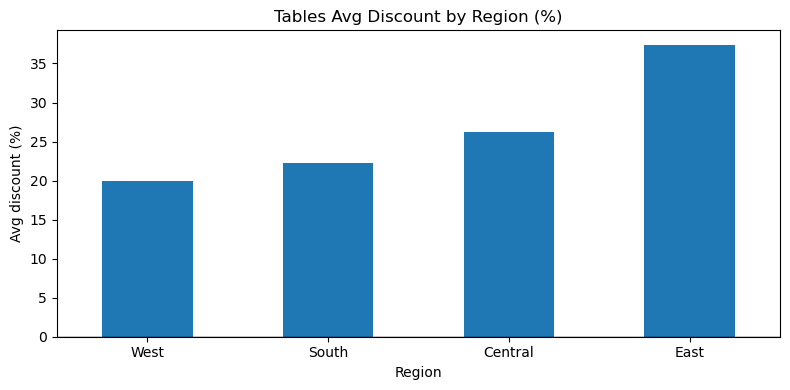

In [23]:
# Plot tables average discount by region
plt.figure(figsize=(8,4))
(summary_of_region_table['Avg Discount']*100).sort_values().plot(kind='bar', color='C0')
plt.axhline(0, color='black', linewidth=1)
plt.title("Tables Avg Discount by Region (%)")
plt.ylabel("Avg discount (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Tables Avg discount by Region (%).png", dpi=300)
plt.show()


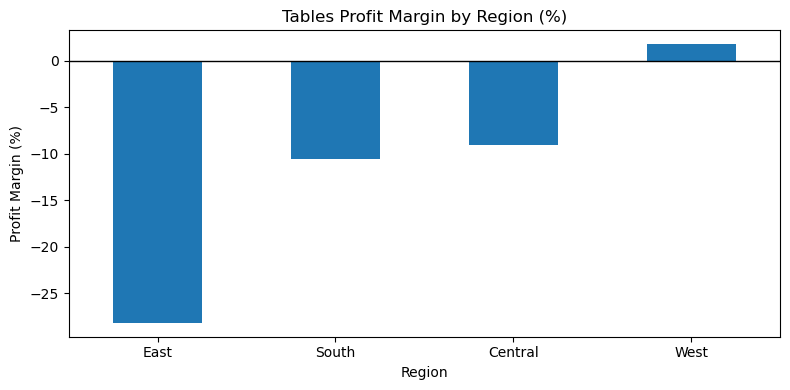

In [24]:
# Plot tables profit margin by region
plt.figure(figsize=(8,4))
(summary_of_region_table['Profit Margin']*100).sort_values().plot(kind='bar', color='C0')
plt.axhline(0, color='black', linewidth=1)
plt.title("Tables Profit Margin by Region (%)")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Tables Profit Margin by Region (%).png", dpi=300)
plt.show()



Regional Profitability - Tables sub-category

Regional decomposition reveals that margin erosion within the Tables sub-category is disproportionately concentrated in the East region.
The East region applies the highest average discount rate (37.4%) and correspondingly exhibits the most severe negative margin (-28.2%). In contrast, the West region maintains the lowest discount level (20.0%) and is the only region generating positive profitability within this sub-category.
This alignment between elevated discounting and margin deterioration suggests that regional pricing strategy—particularly in the East—may be a primary driver of value destruction within Tables.
The evidence indicates that corrective action should prioritize discount discipline and pricing strategy review within specific regions rather than broad category-wide adjustments.

Now that we know that the East is giving more discount than other regions and it is eating into its profit, we want to know why.
Is the East region discounting heavily because it’s selling significantly higher quantities of Tables?

If volume is much higher, maybe the strategy is “low margin, high turnover.”

If volume is not meaningfully higher, then discounting is inefficient.

In [25]:
#Quantity by region for tables
table_quantity = tables_data.groupby('Region', observed=True)[['Quantity', 'Sales','Profit']].sum()
tables_data['Profit Margin'] = table_quantity['Profit'] / table_quantity['Sales']

table_quantity

,Quantity,Sales,Profit
Region,,,
Central,262,39154.971,-3559.6504
East,271,39139.807,-11025.3801
South,227,43916.192,-4623.0579
West,481,84754.562,1482.6073


Average Quantity per Order

We analyze quantity per order to evaluate whether aggressive discounting is driving higher purchase volumes across regions. This metric helps determine whether lower margins are potentially offset by increased unit sales, indicating a volume-based pricing strategy rather than pure margin erosion.

In [26]:
tables_data.groupby('Region',observed=True)['Quantity'].mean()


Region
Central    3.638889
East       3.387500
South      4.450980
West       4.146552
Name: Quantity, dtype: float64

Discount–Quantity Correlation

We compute Correlation between discount levels and quantity sold to assess whether higher discounts meaningfully stimulate demand. A positive and material relationship would suggest that discounting supports a volume-driven strategy, while a weak relationship would indicate limited demand responsiveness and potential inefficiency in pricing decisions.

In [27]:
tables_data[['Discount', 'Quantity']].corr()

,Discount,Quantity
Discount,1.000000,-0.079609
Quantity,-0.079609,1.000000


Volume trade-off tesing - Tables sub-category

Analysis of regional sales volume indicates that elevated discounting in the East region does not translate into materially higher unit sales. The East region does not lead in total quantity sold and exhibits the lowest average quantity per order among all regions.
Furthermore, correlation analysis between discount levels and quantity sold shows a negligible relationship (-0.08), indicating that increased discounting is not meaningfully stimulating additional demand.
These findings suggest that aggressive discounting within the East region is not operating as an effective volume-driven strategy and is instead contributing directly to margin erosion without measurable demand benefits.

SCENARIO ANALYSIS - PRICING INTERVENTION

**Scenario Objective:** Model the impact of reducing East region Tables discount from 37.4% to 25%, holding volume constant.

**Key Assumption:** Sales volume and cost structure remain constant to isolate pricing impact.


In [28]:
#Extract East tables data
east_tables = salesdata[(salesdata['Region'] == 'East') & 
                        (salesdata['Sub-Category'] == 'Tables')].copy()

#Estimated full price
east_tables['Implied Full Price'] = east_tables['Sales'] / (1-east_tables['Discount'])

#Apply new discount
new_discount = 0.25
east_tables['New Sales Price'] = east_tables['Implied Full Price'] * (1 - new_discount)

#Calculate new profit. To do that, we need to calculate cost first from previous Sales and profit
#Cost = Sales - profit

east_tables['Estimated Cost'] = east_tables['Sales'] - east_tables['Profit']

#New profit
east_tables['New Profit'] = east_tables['New Sales Price'] - east_tables['Estimated Cost']

#Compare Old vs New
old_profit = east_tables['Profit'].sum()
new_profit = east_tables['New Profit'].sum()
profit_improvement = new_profit - old_profit

print(f"Original Profit: ${old_profit:,.2f}")
print(f"New Profit (25% discount): ${new_profit:,.2f}")
print(f"Estimated Profit Improvement: ${profit_improvement:,.2f}")


Original Profit: $-11,025.38
New Profit (25% discount): $-2,922.84
Estimated Profit Improvement: $8,102.54


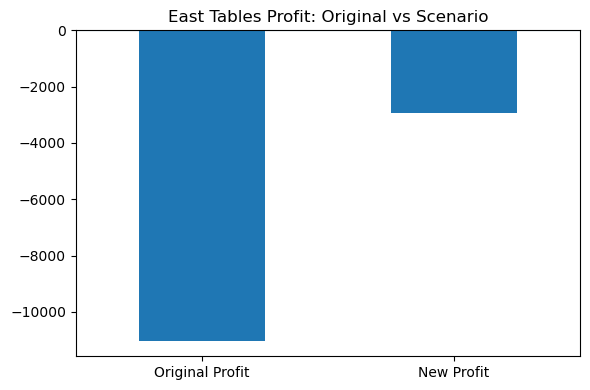

In [29]:
pd.Series({"Original Profit": old_profit,"New Profit": new_profit}).plot(kind='bar', figsize=(6,4))
plt.title("East Tables Profit: Original vs Scenario")
plt.axhline(0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("East Tables Profit.png", dpi=300)
plt.show()


**Scenario Analysis - Pricing intervention Insight**

Reducing the average discount on Tables within the East region from 37.4% to 25% is estimated to improve profitability by approximately $8,103, reducing total losses by nearly 73%.
While the sub-category remains slightly unprofitable under this simplified scenario, the magnitude of improvement confirms that aggressive discounting is a primary driver of margin erosion. The results suggest that targeted pricing discipline could materially mitigate value destruction within this segment.
However, the persistence of residual losses indicates that additional structural factors—such as cost structure or product mix—may also require evaluation.

9. RECOMMENDATIONS AND NEXT STEPS

### Recommendations
- Prioritize discount discipline for Tables in the East region (largest loss concentration and highest discounting).  
- Target interventions at loss-making sub-categories (Tables, Bookcases) rather than broad Furniture-wide actions.  
- Monitor profitability post-intervention and validate with context (competitive pricing, shipping/fulfillment costs, returns).

### Limitations
- Public dataset; no external market context.
- Volume held constant in scenario.
- Costs inferred from available fields.

### Future Enhancements
- Introduce elasticity estimates to model demand response.  
- Build multi-scenario stress tests (discount × region × sub-category). 
- Time-series forecasting.